In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('data/raw/listings.csv')

#Creating missing indicator for price
df['price_missing'] = df['price'].isnull().astype(int)

total_missing = df['price_missing'].sum()
pct_missing = (total_missing / len(df)) * 100

print(f'\nPrice Missing: {total_missing:,} / {len(df):,} ({pct_missing:.2f}%)')


Price Missing: 34,908 / 96,871 (36.04%)


### Test 1: Chi-Square Test for Categorical Values (MCAR Test)

In [3]:
#This test is to check whether there is a correlation between missing values and categorical features

print('H0: Missingness is independent of feature (MCAR)')
print('H1: Missingness depends on feature (MAR/MNAR)')

categorical_features = [col for col in df.select_dtypes(include=['object','category']).columns]

rejected_mcar = []
accepted_mcar = []

for feature in categorical_features:
    if df[feature].nunique() < 100: #Testing only for columns with reasonable cardinality
        continue
    
    # Chi-square test
    contingency = pd.crosstab(df[feature], df['price_missing'])

    if contingency.size == 0:
        print(f"Skipping {feature} due to lack of values for chi-square test")
    else:
        chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    
    print(f'\n{feature} ({df[feature].nunique()} categories):')
    print(f'Chi-square = {chi2:,.2f}')
    
    if p_value == 0.0:
        print(f'Astronomically small P-value')
    else:
        print(f'P-value = {p_value:.6f}')
    
    if p_value < 0.05:
            print(f'Reject H0: Missing related to {feature} (MAR)')
            rejected_mcar.append(feature)
    else:
            print(f'Accept H0: No relationship (MCAR)')
            accepted_mcar.append(feature)

print(f"\nTotal features that: accepted MCAR - {len(accepted_mcar)}, rejected MCAR - {len(rejected_mcar)}")

H0: Missingness is independent of feature (MCAR)
H1: Missingness depends on feature (MAR/MNAR)

listing_url (96871 categories):
Chi-square = 96,871.00
P-value = 0.498489
Accept H0: No relationship (MCAR)

name (93340 categories):
Chi-square = 94,733.03
P-value = 0.000659
Reject H0: Missing related to name (MAR)

description (83379 categories):
Chi-square = 90,066.90
P-value = 0.000000
Reject H0: Missing related to description (MAR)

neighborhood_overview (33388 categories):
Chi-square = 39,198.10
P-value = 0.000000
Reject H0: Missing related to neighborhood_overview (MAR)

picture_url (94609 categories):
Chi-square = 96,041.46
P-value = 0.000518
Reject H0: Missing related to picture_url (MAR)

host_url (55646 categories):
Chi-square = 83,162.67
Astronomically small P-value
Reject H0: Missing related to host_url (MAR)

host_name (16672 categories):
Chi-square = 31,338.02
Astronomically small P-value
Reject H0: Missing related to host_name (MAR)

host_since (5489 categories):
Chi-square 

### Test 2: T-Test for Numeric Variables (MAR test)

In [4]:
#This test is to check whether there is a pattern between values for numerical columns in missing and non-missing data

print('H0: Mean of feature same for missing vs non-missing (MCAR)')
print('H1: Mean differs (MAR)\n')

exclude_cols = ['id', 'host_id', 'latitude', 'longitude', 'price', 'price_missing']
numeric_features = [col for col in df.select_dtypes(include=[np.number]).columns 
                   if col not in exclude_cols]

rejected_mcar = []
accepted_mcar = []

for feature in numeric_features:
    # Splitting by missing/non-missing
    has_price = df[df['price_missing'] == 0][feature].dropna()
    no_price = df[df['price_missing'] == 1][feature].dropna()
    
    if len(has_price) > 0 and len(no_price) > 0:
        # T-test
        t_stat, p_value = stats.ttest_ind(has_price, no_price)
        
        mean_has = has_price.mean()
        mean_no = no_price.mean()
        diff_pct = ((mean_no - mean_has) / mean_has) * 100 if mean_has != 0 else 0
        
        print(f'\n{feature}:')
        print(f'Has price: mean = {mean_has:.2f}')
        print(f'No price:  mean = {mean_no:.2f} ({diff_pct:+.1f}% difference)')
        print(f't-statistic = {t_stat:.2f}, p-value = {p_value:.4f}')
        
        if p_value < 0.05:
            print(f'Reject H0: Missing related to {feature} (MAR)')
            rejected_mcar.append(feature)
        else:
            print(f'Accept H0: No relationship (MCAR)')
            accepted_mcar.append(feature)

print(f"\nTotal features that: accepted MCAR - {len(accepted_mcar)}, rejected MCAR - {len(rejected_mcar)}")

H0: Mean of feature same for missing vs non-missing (MCAR)
H1: Mean differs (MAR)


scrape_id:
Has price: mean = 20250914034649.00
No price:  mean = 20250914034649.00 (+0.0% difference)
t-statistic = nan, p-value = nan
Accept H0: No relationship (MCAR)

host_listings_count:
Has price: mean = 68.43
No price:  mean = 17.53 (-74.4% difference)
t-statistic = 19.08, p-value = 0.0000
Reject H0: Missing related to host_listings_count (MAR)

host_total_listings_count:
Has price: mean = 108.57
No price:  mean = 30.14 (-72.2% difference)
t-statistic = 19.92, p-value = 0.0000
Reject H0: Missing related to host_total_listings_count (MAR)

accommodates:
Has price: mean = 3.51
No price:  mean = 2.99 (-14.9% difference)
t-statistic = 37.81, p-value = 0.0000
Reject H0: Missing related to accommodates (MAR)

bathrooms:
Has price: mean = 1.36
No price:  mean = 1.15 (-15.0% difference)
t-statistic = 3.32, p-value = 0.0009
Reject H0: Missing related to bathrooms (MAR)

bedrooms:
Has price: mean = 1.55
No 

### TEST 3: Logistic Regression (To Predict Missingness)

In [5]:
# This test is to check whether we can predict missingness from other features

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Getting all numeric features
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Excluding irrelevant columns
exclude_cols = ['id', 'host_id', 'latitude', 'longitude', 'price', 'price_missing']
numeric_features = [col for col in numeric_features if col not in exclude_cols]

print(f'Using {len(numeric_features)} numeric features:')

# Preparing feature matrix
X = df[numeric_features].copy()

# Handling missing values in predictors
for col in X.columns:
    if X[col].isnull().any():
        # Try median first
        median_val = X[col].median()
        if pd.isna(median_val):  # If median is NaN, use 0
            X[col] = X[col].fillna(0)
        else:
            X[col] = X[col].fillna(median_val)

# Adding encoded categorical features
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Only keeping categorical with reasonable cardinality
for cat_feature in categorical_features:
    if df[cat_feature].nunique() < 20:  # Only if <20 categories
        le = LabelEncoder()
        X[f'{cat_feature}_encoded'] = le.fit_transform(df[cat_feature].fillna('Unknown')).astype('str')
        print(f'+ Added {cat_feature}_encoded')

print(f'\nTotal features: {X.shape[1]}')

# Target
y = df['price_missing']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f'Train: {len(X_train):,}, Test: {len(X_test):,}')

# Training logistic regression
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

# Predicting probabilities
y_pred_proba = lr.predict_proba(X_test)[:, 1]

# Calculating AUC
auc = roc_auc_score(y_test, y_pred_proba)

print(f'\nResults:')
print(f'  AUC Score: {auc:.3f}')
print()

# Interpretation
if auc > 0.8:
    print('Very high predictability: Strong MAR')
    print('Missingness is highly predictable from features')
elif auc > 0.7:
    print('High predictability: Moderate-Strong MAR')
    print('Missingness is quite predictable from features')
elif auc > 0.6:
    print('Moderate predictability: Weak-Moderate MAR')
    print('Missingness is somewhat predictable from features')
else:
    print('Low predictability: Likely MCAR')
    print('Missingness is not predictable from features')

Using 41 numeric features:
+ Added last_scraped_encoded
+ Added source_encoded
+ Added host_response_time_encoded
+ Added host_is_superhost_encoded
+ Added host_verifications_encoded
+ Added host_has_profile_pic_encoded
+ Added host_identity_verified_encoded
+ Added neighbourhood_encoded
+ Added room_type_encoded
+ Added has_availability_encoded
+ Added calendar_last_scraped_encoded
+ Added instant_bookable_encoded

Total features: 53
Train: 67,809, Test: 29,062

Results:
  AUC Score: 0.510

Low predictability: Likely MCAR
Missingness is not predictable from features


### Visual Comparison

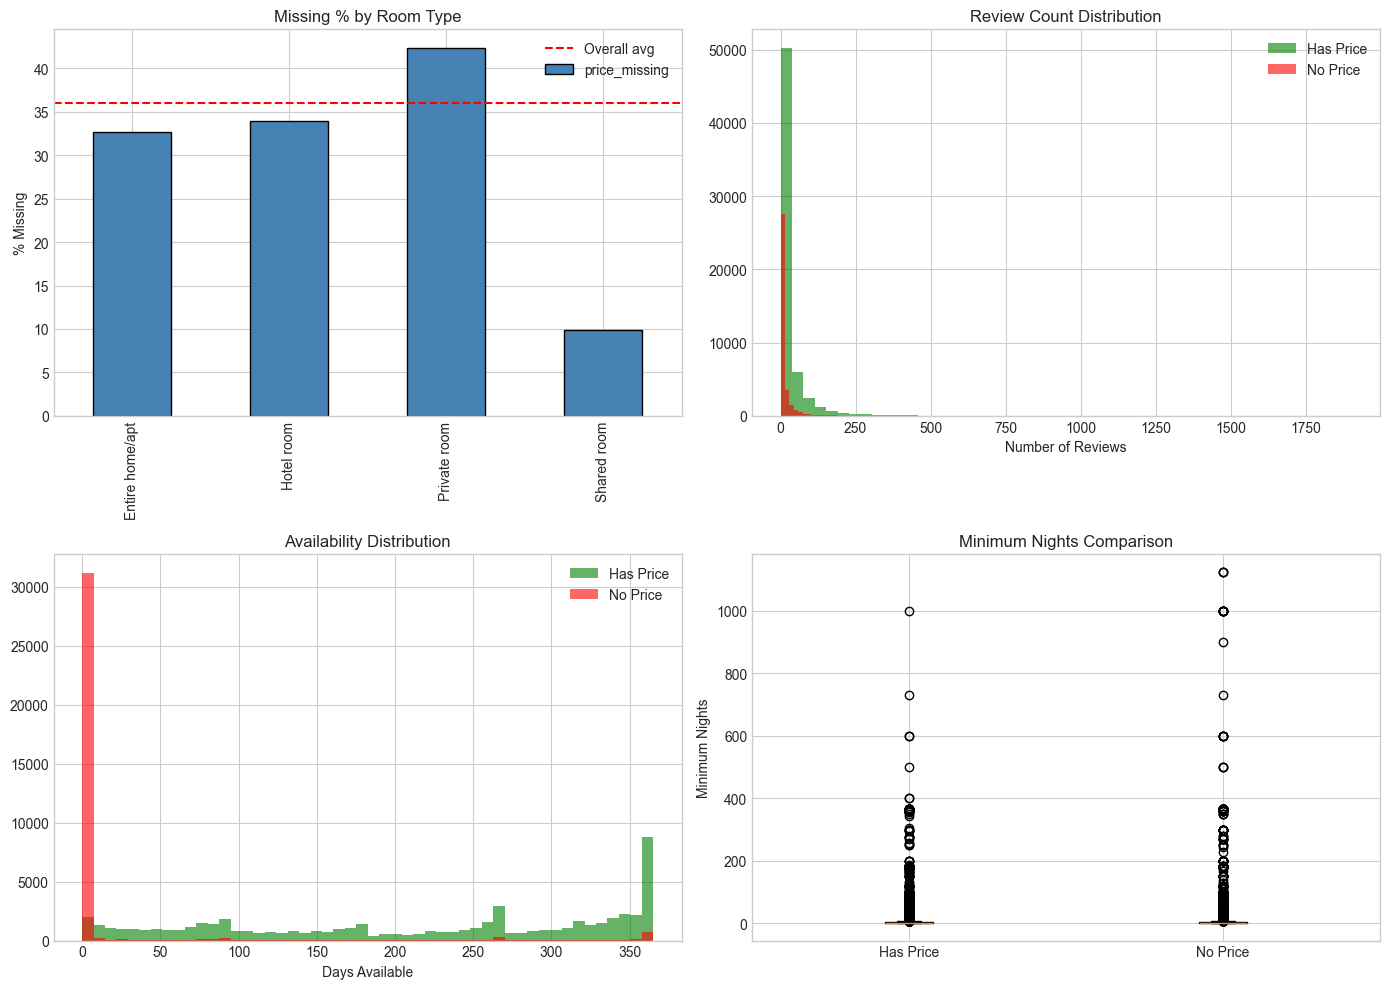

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Missing by room type
if 'room_type' in df.columns:
    missing_by_room = df.groupby('room_type')['price_missing'].mean() * 100
    missing_by_room.plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black')
    axes[0, 0].set(title='Missing % by Room Type', ylabel='% Missing', xlabel='')
    axes[0, 0].axhline(pct_missing, color='red', linestyle='--', label='Overall avg')
    axes[0, 0].legend()

# 2. Review count distribution
if 'number_of_reviews' in df.columns:
    df[df.price_missing == 0]['number_of_reviews'].hist(bins=50, alpha=0.6, 
                                                         label='Has Price', ax=axes[0, 1], color='green')
    df[df.price_missing == 1]['number_of_reviews'].hist(bins=50, alpha=0.6, 
                                                         label='No Price', ax=axes[0, 1], color='red')
    axes[0, 1].set(title='Review Count Distribution', xlabel='Number of Reviews')
    axes[0, 1].legend()

# 3. Availability distribution
if 'availability_365' in df.columns:
    df[df.price_missing == 0]['availability_365'].hist(bins=50, alpha=0.6, 
                                                        label='Has Price', ax=axes[1, 0], color='green')
    df[df.price_missing == 1]['availability_365'].hist(bins=50, alpha=0.6, 
                                                        label='No Price', ax=axes[1, 0], color='red')
    axes[1, 0].set(title='Availability Distribution', xlabel='Days Available')
    axes[1, 0].legend()

# 4. Minimum nights
if 'minimum_nights' in df.columns:
    # Box plot
    data_to_plot = [df[df.price_missing == 0]['minimum_nights'].dropna(),
                    df[df.price_missing == 1]['minimum_nights'].dropna()]
    axes[1, 1].boxplot(data_to_plot, labels=['Has Price', 'No Price'])
    axes[1, 1].set(title='Minimum Nights Comparison', ylabel='Minimum Nights')

plt.tight_layout()
plt.show()

In [7]:
print('Since price is the TARGET variable, imputation is inappropriate.')
print('Dropping null prices is the correct approach for revenue optimimzation modeling.')

df = df.dropna(subset=['price'])

print(f"\nAfter dropping records having no price, we will have: {df.shape[0]} rows x {df.shape[1]-1} features")
print("Next Step: EDA")

Since price is the TARGET variable, imputation is inappropriate.
Dropping null prices is the correct approach for revenue optimimzation modeling.

After dropping records having no price, we will have: 61963 rows x 79 features
Next Step: EDA
